# Docling Enhanced Extraction Test

Testing Docling's full extraction pipeline — tables, figures, formulas, charts — on local research paper PDFs.
**VlmPipeline is excluded** (hardware limitation).


## 1. Install & Import Dependencies


In [1]:
import subprocess, sys

# Install docling if not present
try:
    import docling
    # print(f"docling already installed: {docling.__version__}")
    
except ImportError:
    print("Installing docling...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "docling", "-q"])
    print("docling installed successfully")


In [2]:
import time
import json
from pathlib import Path

from docling.document_converter import DocumentConverter, PdfFormatOption
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import PdfPipelineOptions, AcceleratorOptions, AcceleratorDevice

print("All imports successful.")


/home/aman/storage/Python/Projects/Research Paper Assistant/env_research/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports successful.


## 2. Configure PDF Pipeline Options

Enabling table structure, figure image extraction, and formula enrichment.
`images_scale=2.0` improves image resolution.

Running on **CPU** via `AcceleratorOptions(device=AcceleratorDevice.CPU)` — set `num_threads` to match your core count.
**VlmPipeline excluded** — too expensive for this hardware.


In [3]:
# Force CPU execution — no GPU/MPS required
accelerator_options = AcceleratorOptions(
    num_threads=4,                    # Adjust to your CPU core count
    device=AcceleratorDevice.CPU,
)

pipeline_options = PdfPipelineOptions(
    do_table_structure=True,          # Extract tables with full row/column structure
    generate_picture_images=True,     # Extract figures as actual images
    do_formula_enrichment=True,       # Enrich formulas (LaTeX-level output)
    images_scale=2.0,                 # 2x resolution for extracted images
    accelerator_options=accelerator_options,
    # VlmPipeline intentionally excluded — not feasible on this hardware
)

print("Pipeline options configured:")
print(f"  device                 = {accelerator_options.device}")
print(f"  num_threads            = {accelerator_options.num_threads}")
print(f"  do_table_structure     = {pipeline_options.do_table_structure}")
print(f"  generate_picture_images= {pipeline_options.generate_picture_images}")
print(f"  do_formula_enrichment  = {pipeline_options.do_formula_enrichment}")
print(f"  images_scale           = {pipeline_options.images_scale}")


Pipeline options configured:
  device                 = AcceleratorDevice.CPU
  num_threads            = 4
  do_table_structure     = True
  generate_picture_images= True
  do_formula_enrichment  = True
  images_scale           = 2.0


## 3. Convert PDF Document

Using `Gated Attention.pdf` from the `input/` folder. Timing the conversion to gauge hardware performance.


In [4]:
# Point to a PDF in the input/ folder (change the filename as needed)
PDF_PATH = Path("../input/Gated Attention.pdf")

assert PDF_PATH.exists(), f"PDF not found: {PDF_PATH.resolve()}"

converter = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_options)
    }
)

print(f"Converting: {PDF_PATH.name}")
t_start = time.perf_counter()
result = converter.convert(str(PDF_PATH))
elapsed = time.perf_counter() - t_start

doc = result.document
print(f"\nConversion completed in {elapsed:.2f}s")
print(f"Pages       : {result.document.num_pages()}")
print(f"Text blocks : {len(list(doc.texts))}")
print(f"Tables      : {len(list(doc.tables))}")
print(f"Figures     : {len(list(doc.pictures))}")


Converting: Gated Attention.pdf


[INFO] 2026-03-08 16:41:57,379 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-03-08 16:41:57,386 [RapidOCR] download_file.py:60: File exists and is valid: /home/aman/storage/Python/Projects/Research Paper Assistant/env_research/lib/python3.12/site-packages/rapidocr/models/ch_PP-OCRv4_det_infer.onnx
[INFO] 2026-03-08 16:41:57,386 [RapidOCR] main.py:53: Using /home/aman/storage/Python/Projects/Research Paper Assistant/env_research/lib/python3.12/site-packages/rapidocr/models/ch_PP-OCRv4_det_infer.onnx
[INFO] 2026-03-08 16:41:57,500 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-03-08 16:41:57,502 [RapidOCR] download_file.py:60: File exists and is valid: /home/aman/storage/Python/Projects/Research Paper Assistant/env_research/lib/python3.12/site-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_infer.onnx
[INFO] 2026-03-08 16:41:57,502 [RapidOCR] main.py:53: Using /home/aman/storage/Python/Projects/Research Paper Assistant/env_research/lib/python3.12/


Conversion completed in 192.63s
Pages       : 17
Text blocks : 652
Tables      : 6
Figures     : 10


## 4. Export to Multiple Formats

Docling supports JSON, Markdown, HTML, and plain text exports. JSON is the most complete — it preserves the full element hierarchy.


In [6]:
stem = PDF_PATH.stem  # e.g. "Gated Attention"

# --- JSON (most complete) ---
# DoclingDocument is a Pydantic model — use model_dump_json() instead of export_to_json()
json_output = doc.model_dump_json(indent=2)
json_path = Path(f"{stem}_docling.json")
json_path.write_text(json_output, encoding="utf-8")
print(f"JSON saved  -> {json_path}  ({json_path.stat().st_size / 1024:.1f} KB)")
print("Preview (first 400 chars):")
print(json_output[:400])
print("...")


JSON saved  -> Gated Attention_docling.json  (2276.0 KB)
Preview (first 400 chars):
{
  "schema_name": "DoclingDocument",
  "version": "1.9.0",
  "name": "Gated Attention",
  "origin": {
    "mimetype": "application/pdf",
    "binary_hash": 12255005367121945433,
    "filename": "Gated Attention.pdf",
    "uri": null
  },
  "furniture": {
    "self_ref": "#/furniture",
    "parent": null,
    "children": [],
    "content_layer": "furniture",
    "meta": null,
    "name": "_root_",
...


In [7]:
# --- Markdown ---
md_output = doc.export_to_markdown()
md_path = Path(f"{stem}_docling.md")
md_path.write_text(md_output, encoding="utf-8")
print(f"Markdown saved -> {md_path}")
print("\nPreview (first 600 chars):")
print(md_output[:600])
print("...")


Markdown saved -> Gated Attention_docling.md

Preview (first 600 chars):
<!-- image -->

## Gated Attention for Large Language Models: Non-linearity, Sparsity, and Attention-Sink-Free

Zihan Qiu ∗ 1 , Zekun Wang ∗ 1 , Bo Zheng ∗ 1 , Zeyu Huang ∗ 2 , Kaiyue Wen 3 , Songlin Yang 4 , Rui Men 1 , Le Yu 1 , Fei Huang 1 , Suozhi Huang 5 Dayiheng Liu B 1 , Jingren Zhou 1 , Junyang Lin B 1 1 2 3 Stanford University

Qwen Team, Alibaba Group University of Edinburgh 4 MIT 5 Tsinghua University

## Abstract

Gating mechanisms have been widely utilized, from early models like LSTMs (Hochreiter &amp;Schmidhuber, 1997) and Highway Networks (Srivastava et al., 2015) to recent sta
...


In [8]:
# --- HTML ---
html_output = doc.export_to_html()
html_path = Path(f"{stem}_docling.html")
html_path.write_text(html_output, encoding="utf-8")
print(f"HTML saved  -> {html_path}")

# --- Plain text ---
text_output = doc.export_to_text()
txt_path = Path(f"{stem}_docling.txt")
txt_path.write_text(text_output, encoding="utf-8")
print(f"Text saved  -> {txt_path}")
print("\nPlain text preview (first 400 chars):")
print(text_output[:400])


Parameter `strict_text` has been deprecated and will be ignored.


HTML saved  -> Gated Attention_docling.html
Text saved  -> Gated Attention_docling.txt

Plain text preview (first 400 chars):
## Gated Attention for Large Language Models: Non-linearity, Sparsity, and Attention-Sink-Free

Zihan Qiu ∗ 1 , Zekun Wang ∗ 1 , Bo Zheng ∗ 1 , Zeyu Huang ∗ 2 , Kaiyue Wen 3 , Songlin Yang 4 , Rui Men 1 , Le Yu 1 , Fei Huang 1 , Suozhi Huang 5 Dayiheng Liu B 1 , Jingren Zhou 1 , Junyang Lin B 1 1 2 3 Stanford University

Qwen Team, Alibaba Group University of Edinburgh 4 MIT 5 Tsinghua University



## 5. Extract & Inspect Text Blocks and Headings


In [9]:
from docling_core.types.doc import DocItemLabel

# Separate headings from body text
headings = []
paragraphs = []
list_items = []

for item, _level in doc.iterate_items():
    label = str(item.label).lower()
    if "section_header" in label or "title" in label:
        headings.append((item.text, _level))
    elif "list_item" in label:
        list_items.append(item.text)
    elif "text" in label:
        paragraphs.append(item.text)

print("=" * 62)
print("SECTION HIERARCHY")
print("=" * 62)
for text, lvl in headings:
    indent = "  " * max(0, lvl - 1)
    print(f"{indent}- {text}")

print(f"\nTotal paragraphs : {len(paragraphs)}")
print(f"Total list items : {len(list_items)}")


SECTION HIERARCHY
- Gated Attention for Large Language Models: Non-linearity, Sparsity, and Attention-Sink-Free
- Abstract
- 1 Introduction
- 2 Gated-Attention Layer
- 2.1 Preliminary: Multi-Head Softmax Attention
- 2.2 Augmenting Attention Layer with Gating Mechanisms
- 3 Experiments
- 3.1 Experimental Setups
- 3.2 Main Results
- 3.2.1 Gated Attention for MoE models
- 3.2.2 Gated Attention for Dense Models.
- 4 Analysis: Non-Linearity, Sparsity, and Attention-Sink-Free
- 4.1 Non-linearity Improves the Expressiveness of Low-Rank Mapping in Attention
- 4.2 Gating Introduces Input-Dependent Sparsity
- 4.3 SDPA Output Gating Reduces Attention-Sink
- 4.4 SDPA Output Gating Facilitates Context Length Extension
- 5 Related Works
- 5.1 Gating in Neural Networks
- 5.2 Attention Sink
- 6 Conclusion
- Limitations
- References
- A Supplement Experiments
- A.1 Switch Head Baselines
- A.2 More Discussion on Sparse Gating Score
- A.3 Layerwise Massive Activations and Attention Sinks
- A.4 More Layer

In [10]:
# Preview first 5 paragraphs
print("First 5 paragraphs:")
print("-" * 62)
for i, p in enumerate(paragraphs[:5], 1):
    print(f"[{i}] {p[:200]}")
    print()


First 5 paragraphs:
--------------------------------------------------------------
[1] Zihan Qiu ∗ 1 , Zekun Wang ∗ 1 , Bo Zheng ∗ 1 , Zeyu Huang ∗ 2 , Kaiyue Wen 3 , Songlin Yang 4 , Rui Men 1 , Le Yu 1 , Fei Huang 1 , Suozhi Huang 5 Dayiheng Liu B 1 , Jingren Zhou 1 , Junyang Lin B 1 

[2] Qwen Team, Alibaba Group University of Edinburgh 4 MIT 5 Tsinghua University

[3] Gating mechanisms have been widely utilized, from early models like LSTMs (Hochreiter &Schmidhuber, 1997) and Highway Networks (Srivastava et al., 2015) to recent state space models (Gu & Dao, 2023), 

[4] Gating mechanism is well-established in neural networks. Early architectures, such as LSTMs (Hochreiter & Schmidhuber, 1997), Highway Networks (Srivastava et al., 2015) and GRUs (Dey & Salem, 2017), p

[5] Insufficient understanding hinders assessing gating's true contribution, especially when confounded with other architectural factors. For instance, while Switch Heads (Csordas et al., 2024a;b) introdu



## 6. Extract & Inspect Tables


In [11]:
import pandas as pd

tables = list(doc.tables)
print(f"Total tables found: {len(tables)}")
print("=" * 62)

for i, table in enumerate(tables, 1):
    caption = table.caption_text(doc) or "(no caption)"
    page = table.prov[0].page_no if table.prov else "?"
    print(f"\nTable {i} — Page {page}")
    print(f"Caption: {caption}")

    # Export to DataFrame for easy inspection
    try:
        df = table.export_to_dataframe()
        print(f"Shape  : {df.shape[0]} rows x {df.shape[1]} cols")
        display(df)
    except Exception as e:
        print(f"  Could not export to DataFrame: {e}")


Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.


Total tables found: 6

Table 1 — Page 4
Caption: Table 1: Gating variant performance and results. We train the 15A2B MoE models on 400B tokens. d k is the head dim, d model is the model's hidden dim, and n is the number of tokens. q refers to the number of query heads, k refers to the number of key-value heads. 'Act Func' is the activation function in Eq 5. 'Score Shape' is the gating score shape for an input X ∈ R n , d model . 'added param' indicates added parameters (Million).
Shape  : 19 rows x 9 cols


,Method,Act Func,Score Shape,Added Param,Avg PPL,Hellaswag,MMLU,GSM8k,C-eval
0,"Reference Baselines (Baseline uses q = 32, k =...","Reference Baselines (Baseline uses q = 32, k =...","Reference Baselines (Baseline uses q = 32, k =...","Reference Baselines (Baseline uses q = 32, k =...","Reference Baselines (Baseline uses q = 32, k =...","Reference Baselines (Baseline uses q = 32, k =...","Reference Baselines (Baseline uses q = 32, k =...","Reference Baselines (Baseline uses q = 32, k =...","Reference Baselines (Baseline uses q = 32, k =..."
1,(1) Baseline,-,-,0,6.026,73.07,58.79,52.92,60.26
2,(2) k = 8,-,-,50,5.979,73.51,59.78,52.16,62.26
3,(3) q = 48,-,-,201,5.953,73.59,58.45,53.30,59.67
4,(4) Add 4 Experts,-,-,400,5.964,73.19,58.84,52.54,63.19
5,Gating Position Variants,Gating Position Variants,Gating Position Variants,Gating Position Variants,Gating Position Variants,Gating Position Variants,Gating Position Variants,Gating Position Variants,Gating Position Variants
6,(5) SDPA Elementwise G 1 (6) v Elementwise G 2...,sigmoid,n × q × d k,201,5.761,74.64,60.82,55.27,62.20
7,,sigmoid,n × k × d k,25,5.820,74.38,59.17,53.97,61.00
8,,sigmoid,n × k × d k,25,6.016,72.88,59.18,50.49,61.74
9,(8) q Elementwise G 4,sigmoid,n × q × d k,201,5.981,73.01,58.74,53.97,62.14


Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.



Table 2 — Page 5
Caption: Table 2: Performance of different methods with varying learning rates, batch sizes, and model configurations. 'SDPA' refers to the sigmoid gating after SDPA in Eq 3, and 'sandwitch norm' (Ding et al., 2021) indicates normalizing attention/ffn outputs before adding them to the residual. When using gating, we reduce the FFN's width so that all methods have the same number of parameters. '-' means the model diverges during training.
Shape  : 15 rows x 9 cols


...


Table 5 — Page 8
Caption: Table 5: Performance of different methods across varying sequence lengths. 'YaRN Extended' indicates the expanded context length variant. '(values)' indicate the performance declines after extending the context length.
Shape  : 5 rows x 7 cols


,Method,4k,8k,16k,32k,64k,128k
0,Baseline,88.89,85.88,83.15,79.50,-,-
1,SDPA-Gate,90.56,87.11,84.61,79.77,-,-
2,YaRN Extended,YaRN Extended,YaRN Extended,YaRN Extended,YaRN Extended,YaRN Extended,YaRN Extended
3,Baseline,82.90(-6.0),71.52(-14.4),61.23(-21.9),37.94(-41.56),37.51,31.65
4,SDPA-Gate,88.13(-2.4),80.01(-7.1),76.74(-7.87),72.88(-6.89),66.60,58.82


Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.



Table 6 — Page 13
Caption: Table 6: Performance of different switch head methods with varying parameter additions and configurations. 'switch kv' and 'switch v' refer to introducing selective computing in key-value and value components, respectively. 'Switch kv, 8top8' means there are 8 key and value map experts, and each token select top8 experts. Notice 'Switch v, 1top1' is equivalent to v Headwise Gate in Tab. 1 row (11).
Shape  : 6 rows x 7 cols


,Method,Added Param (M),PPL,MMLU,GSM8k,Hellaswag,C-eval
0,"(1) Baseline (q32, kv4)",-,6.026,58.79,52.92,73.07,60.26
1,"(2) Switch kv, 8top8",38,5.847,59.17,52.54,73.32,61.01
2,"(3) Switch kv, 4top4",13,5.935,58.14,53.27,73.75,59.67
3,"(4) Switch v, 4top4",13,5.820,59.02,52.77,73.34,61.74
4,"(5) Switch v, 8top2",25,5.870,59.10,53.53,74.17,62.34
5,"(6) Switch v, 1top1",3,5.808,59.32,53.53,74.38,62.61


## 7. Extract & Inspect Figures

`generate_picture_images=True` means each figure has an actual `PIL.Image` attached. Displaying them inline here.


Total figures found: 10

Figure 1 — Page 1
Caption: (no caption)


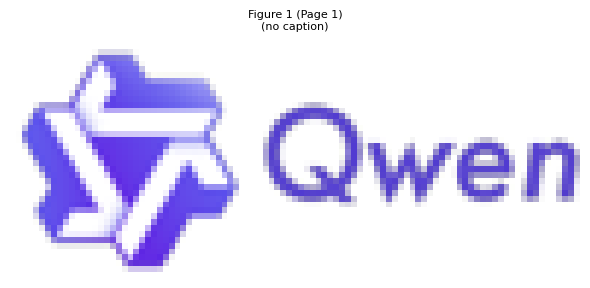


Figure 2 — Page 2
Caption: Figure 1: Left : Investigated positions for applying gating operations.; Middle : Performance comparison (Test PPL and M


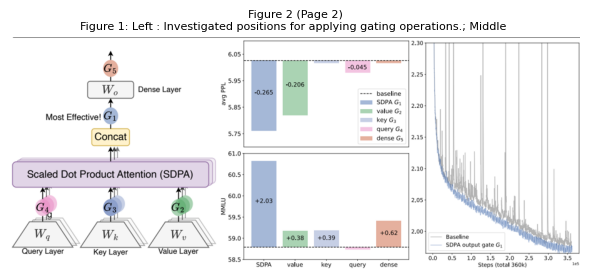


Figure 3 — Page 3
Caption: Figure 2: Left : Proportion of attention allocated to the initial token per layer (test perplexity dataset). The baselin


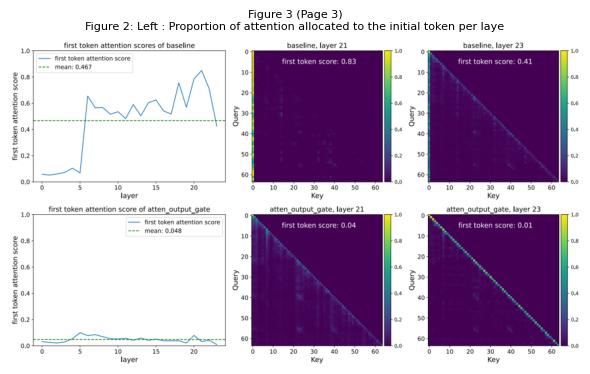


Figure 4 — Page 7
Caption: Figure 3: Gating score means and distributions for SDPA elementwise (Left), value Elementwise (Middle), and SDPA element


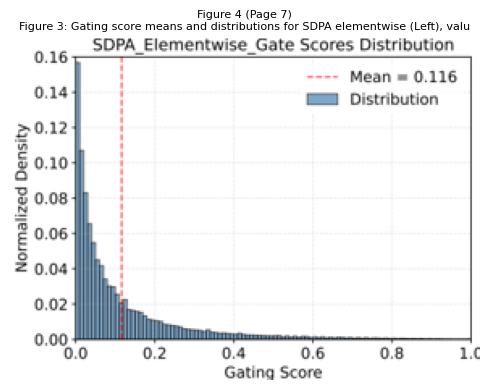


Figure 5 — Page 7
Caption: (no caption)


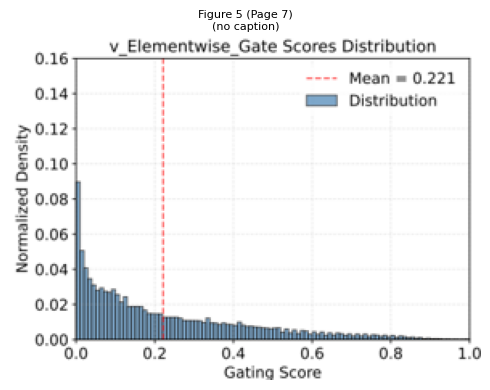


Figure 6 — Page 7
Caption: (no caption)


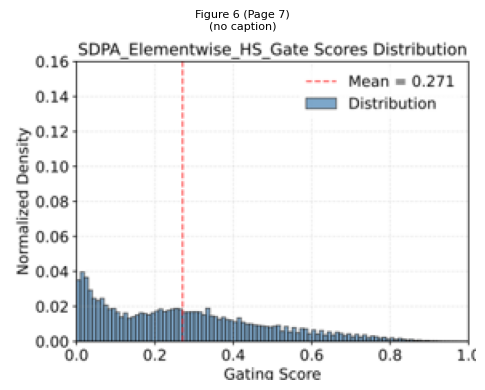


Figure 7 — Page 14
Caption: Figure 4: Mean absolute values before and after gating. The baseline and post-gating values are similar.


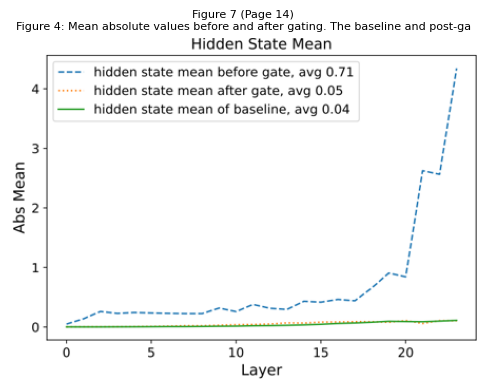


Figure 8 — Page 14
Caption: Figure 5: Proportion of SDPA output values below threshold after gating (Left: 1e-2, Right: 1e-3). We also include spars


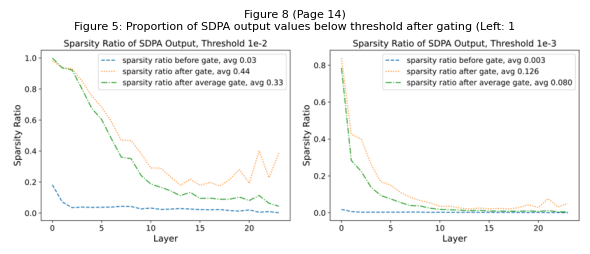


Figure 9 — Page 16
Caption: (no caption)


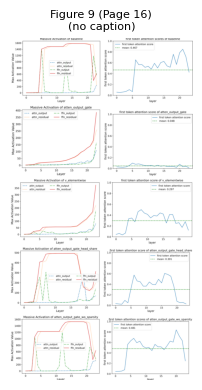


Figure 10 — Page 17
Caption: Figure 7: Distribution of gating scores under different constraints for SDPA output gating variants.


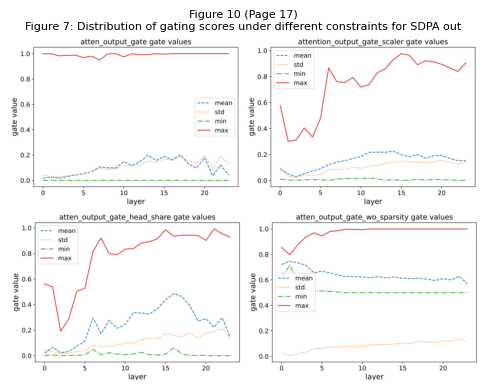

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

pictures = list(doc.pictures)
print(f"Total figures found: {len(pictures)}")

for i, pic in enumerate(pictures, 1):
    caption = pic.caption_text(doc) or "(no caption)"
    page = pic.prov[0].page_no if pic.prov else "?"
    print(f"\nFigure {i} — Page {page}")
    print(f"Caption: {caption[:120]}")

    # get_image() returns a PIL Image if generate_picture_images=True
    try:
        pil_img = pic.get_image(doc)
        if pil_img:
            fig, ax = plt.subplots(figsize=(6, 4))
            ax.imshow(pil_img)
            ax.set_title(f"Figure {i} (Page {page})\n{caption[:80]}", fontsize=8)
            ax.axis("off")
            plt.tight_layout()
            plt.show()
        else:
            print("  (image data not available)")
    except Exception as e:
        print(f"  Could not display image: {e}")


## 8. Extract & Inspect Formulas

With `do_formula_enrichment=True`, inline and display formulas should be enriched with LaTeX.


In [13]:
from IPython.display import Math, display as ipy_display

formulas = []
for item, _level in doc.iterate_items():
    label = str(item.label).lower()
    if "formula" in label or "equation" in label:
        formulas.append(item)

print(f"Total formulas found: {len(formulas)}")
print("=" * 62)

for i, f in enumerate(formulas, 1):
    raw = f.text or ""
    page = f.prov[0].page_no if f.prov else "?"
    print(f"\nFormula {i} — Page {page}")
    print(f"Raw text : {raw}")

    # Try to render as LaTeX if available
    latex = getattr(f, "orig", None) or raw
    if latex and latex.strip():
        # Strip surrounding $$ or $ if present so Math() renders cleanly
        clean = latex.strip().strip("$")
        try:
            ipy_display(Math(clean))
        except Exception:
            pass  # Not all formulas will be valid LaTeX


Total formulas found: 9

Formula 1 — Page 2
Raw text : Q = X W _ { Q } , \quad K = X W _ { K } , \quad V = X V _ { V } .


<IPython.core.display.Math object>


Formula 2 — Page 2
Raw text : \text {Attention} ( Q ; K , V ) = \text {softmax} \left ( \frac { Q K ^ { T } } { \sqrt { d _ { k } } } \right ) V ,


<IPython.core.display.Math object>


Formula 3 — Page 2
Raw text : M u t i { I } { \text {Head} } ( \mathcal { L } , K , V ) = \text {Concat} ( \text {head} _ { 1 } , \dots , \text {head} _ { h } ) ,


...

<IPython.core.display.Math object>


Formula 8 — Page 6
Raw text : o _ { i } ^ { k } = \text {Non-Linearity-Map} \left ( \sum \nolimits _ { j = 0 } ^ { i } S _ { i j } ^ { k } \cdot X _ { j } W _ { V } ^ { k } \right ) W _ { O } ^ { k } .


<IPython.core.display.Math object>


Formula 9 — Page 7
Raw text : N S \text {-sigmoid} ( x ) = 0 . 5 + 0 . 5 \cdot \text {sigmoid} ( x ) ,


<IPython.core.display.Math object>

## 9. Enable Chart Extraction

Re-run conversion with `do_chart_extraction=True` and compare results against the baseline.
> Note: This will trigger another full conversion pass — observe the timing difference.


In [14]:
chart_pipeline_options = PdfPipelineOptions(
    do_table_structure=True,
    generate_picture_images=True,
    do_formula_enrichment=True,
    images_scale=2.0,
    do_chart_extraction=True,          # NEW — extract bar/pie/line charts
    accelerator_options=accelerator_options,  # same CPU config
)

chart_converter = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(pipeline_options=chart_pipeline_options)
    }
)

print("Converting with chart extraction enabled (CPU)...")
t0 = time.perf_counter()
chart_result = chart_converter.convert(str(PDF_PATH))
chart_elapsed = time.perf_counter() - t0
chart_doc = chart_result.document

chart_pics = list(chart_doc.pictures)
baseline_pics = len(pictures)

print(f"Chart-enabled conversion: {chart_elapsed:.2f}s  (baseline: {elapsed:.2f}s)")
print(f"Figures (baseline)       : {baseline_pics}")
print(f"Figures (with charts)    : {len(chart_pics)}")
print(f"Potential chart elements : {len(chart_pics) - baseline_pics}")


[INFO] 2026-03-08 16:50:49,574 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-03-08 16:50:49,586 [RapidOCR] download_file.py:60: File exists and is valid: /home/aman/storage/Python/Projects/Research Paper Assistant/env_research/lib/python3.12/site-packages/rapidocr/models/ch_PP-OCRv4_det_infer.onnx
[INFO] 2026-03-08 16:50:49,587 [RapidOCR] main.py:53: Using /home/aman/storage/Python/Projects/Research Paper Assistant/env_research/lib/python3.12/site-packages/rapidocr/models/ch_PP-OCRv4_det_infer.onnx
[INFO] 2026-03-08 16:50:49,691 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-03-08 16:50:49,695 [RapidOCR] download_file.py:60: File exists and is valid: /home/aman/storage/Python/Projects/Research Paper Assistant/env_research/lib/python3.12/site-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_infer.onnx
[INFO] 2026-03-08 16:50:49,696 [RapidOCR] main.py:53: Using /home/aman/storage/Python/Projects/Research Paper Assistant/env_research/lib/python3.12/

Converting with chart extraction enabled (CPU)...


[INFO] 2026-03-08 16:50:49,748 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-03-08 16:50:49,771 [RapidOCR] download_file.py:60: File exists and is valid: /home/aman/storage/Python/Projects/Research Paper Assistant/env_research/lib/python3.12/site-packages/rapidocr/models/ch_PP-OCRv4_rec_infer.onnx
[INFO] 2026-03-08 16:50:49,771 [RapidOCR] main.py:53: Using /home/aman/storage/Python/Projects/Research Paper Assistant/env_research/lib/python3.12/site-packages/rapidocr/models/ch_PP-OCRv4_rec_infer.onnx


Chart-enabled conversion: 181.44s  (baseline: 192.63s)
Figures (baseline)       : 10
Figures (with charts)    : 10
Potential chart elements : 0


## 10. Traverse JSON Hierarchy Programmatically

Load the saved JSON and recursively walk the entire element tree to count and categorise every element type.


In [15]:
from collections import defaultdict

# Load the JSON export we saved earlier
with open(json_path, "r", encoding="utf-8") as f:
    doc_json = json.load(f)

# ── helpers ────────────────────────────────────────────────────────────────
def walk(node: dict | list, counts: dict, depth: int = 0) -> None:
    """Recursively walk the Docling JSON structure counting element labels."""
    if isinstance(node, dict):
        label = node.get("label") or node.get("type")
        if label:
            counts[label] += 1
        for v in node.values():
            walk(v, counts, depth + 1)
    elif isinstance(node, list):
        for item in node:
            walk(item, counts, depth)


def summarise(doc_json: dict) -> dict:
    counts = defaultdict(int)
    walk(doc_json, counts)
    return dict(sorted(counts.items(), key=lambda x: -x[1]))


# ── run ─────────────────────────────────────────────────────────────────────
element_counts = summarise(doc_json)

print(f"{'Element Label':<30} {'Count':>6}")
print("-" * 38)
for label, count in element_counts.items():
    print(f"{label:<30} {count:>6}")


Element Label                   Count
--------------------------------------
text                              516
list_item                          63
section_header                     30
page_footer                        17
caption                            13
picture                            10
formula                             9
table                               6
list                                5
unspecified                         2
page_header                         2
footnote                            2


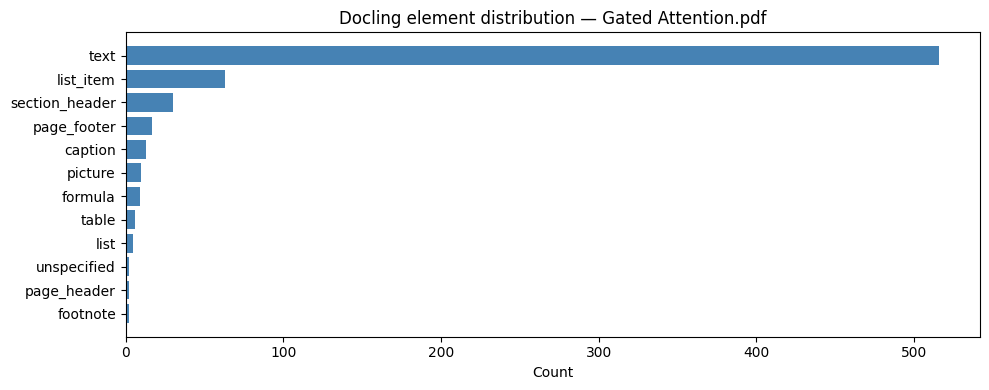

In [16]:
# Bar chart of element distribution
labels = list(element_counts.keys())[:20]       # Top 20
counts_vals = [element_counts[l] for l in labels]

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(labels[::-1], counts_vals[::-1], color="steelblue")
ax.set_xlabel("Count")
ax.set_title(f"Docling element distribution — {PDF_PATH.name}")
plt.tight_layout()
plt.show()


In [ ]:
## 11. Annotate PDF with Colored Bounding Boxes

# Draw category-colored borders directly on the PDF pages and save the result.

# | Category | Color |
# |---|---|
# | Text / paragraph | Green |
# | Section header / title | Blue |
# | Table | Orange |
# | Figure / picture | Yellow |
# | Formula / equation | Red |
# | List item | Purple |


In [26]:
import fitz  # PyMuPDF

# ── Color map (RGB 0-1 floats) ─────────────────────────────────────────────
COLOR_MAP = {
    "text":           (0.13, 0.69, 0.30),   # green
    "section_header": (0.20, 0.47, 0.90),   # blue
    "title":          (0.20, 0.47, 0.90),   # blue
    "table":          (0.96, 0.49, 0.00),   # orange
    "picture":        (0.95, 0.85, 0.00),   # yellow
    "formula":        (0.90, 0.10, 0.10),   # red
    "equation":       (0.90, 0.10, 0.10),   # red
    "list_item":      (0.60, 0.10, 0.80),   # purple
}
DEFAULT_COLOR = (0.55, 0.55, 0.55)          # grey for anything else

def docling_to_fitz_rect(bbox, page_height: float) -> fitz.Rect:
    """Convert Docling BOTTOMLEFT-origin bbox → PyMuPDF TOPLEFT-origin Rect."""
    return fitz.Rect(
        bbox.l,
        page_height - bbox.t,
        bbox.r,
        page_height - bbox.b,
    )

# ── Open source PDF ────────────────────────────────────────────────────────
pdf_doc = fitz.open(str(PDF_PATH))

# Cache page heights (avoids repeated attribute access)
page_heights = {i: pdf_doc[i].rect.height for i in range(len(pdf_doc))}

highlight_counts = defaultdict(int)

# ── 1. Text / headings / list items / formulas ────────────────────────────
for item, _level in doc.iterate_items():
    label = str(item.label).lower()
    color = COLOR_MAP.get(label, DEFAULT_COLOR)

    if not item.prov:
        continue
    for prov in item.prov:
        page_no = prov.page_no - 1          # Docling is 1-indexed
        if page_no < 0 or page_no >= len(pdf_doc):
            continue
        ph = page_heights[page_no]
        rect = docling_to_fitz_rect(prov.bbox, ph)
        page = pdf_doc[page_no]
        page.draw_rect(rect, color=color, width=1.2)
        highlight_counts[label] += 1

# ── 2. Tables ─────────────────────────────────────────────────────────────
color = COLOR_MAP["table"]
for table in doc.tables:
    if not table.prov:
        continue
    for prov in table.prov:
        page_no = prov.page_no - 1
        if page_no < 0 or page_no >= len(pdf_doc):
            continue
        ph = page_heights[page_no]
        rect = docling_to_fitz_rect(prov.bbox, ph)
        pdf_doc[page_no].draw_rect(rect, color=color, width=2.0)
        highlight_counts["table"] += 1

# ── 3. Figures ────────────────────────────────────────────────────────────
color = COLOR_MAP["picture"]
for pic in doc.pictures:
    if not pic.prov:
        continue
    for prov in pic.prov:
        page_no = prov.page_no - 1
        if page_no < 0 or page_no >= len(pdf_doc):
            continue
        ph = page_heights[page_no]
        rect = docling_to_fitz_rect(prov.bbox, ph)
        pdf_doc[page_no].draw_rect(rect, color=color, width=2.0)
        highlight_counts["picture"] += 1

# ── Save ──────────────────────────────────────────────────────────────────
output_pdf = Path(f"{stem}_annotated.pdf")
pdf_doc.save(str(output_pdf))
pdf_doc.close()

print(f"Annotated PDF saved → {output_pdf}")
print(f"\nAnnotations drawn:")
for cat, cnt in sorted(highlight_counts.items(), key=lambda x: -x[1]):
    color_name = {
        "text": "green", "section_header": "blue", "title": "blue",
        "table": "orange", "picture": "yellow", "formula": "red",
        "equation": "red", "list_item": "purple",
    }.get(cat, "grey")
    print(f"  {cat:<20} {cnt:>4}  ({color_name})")


Annotated PDF saved → Gated Attention_annotated.pdf

Annotations drawn:
  list_item              63  (purple)
  text                   62  (green)
  section_header         28  (blue)
  picture                20  (yellow)
  caption                13  (grey)
  table                  12  (orange)
  formula                 9  (red)
  footnote                2  (grey)


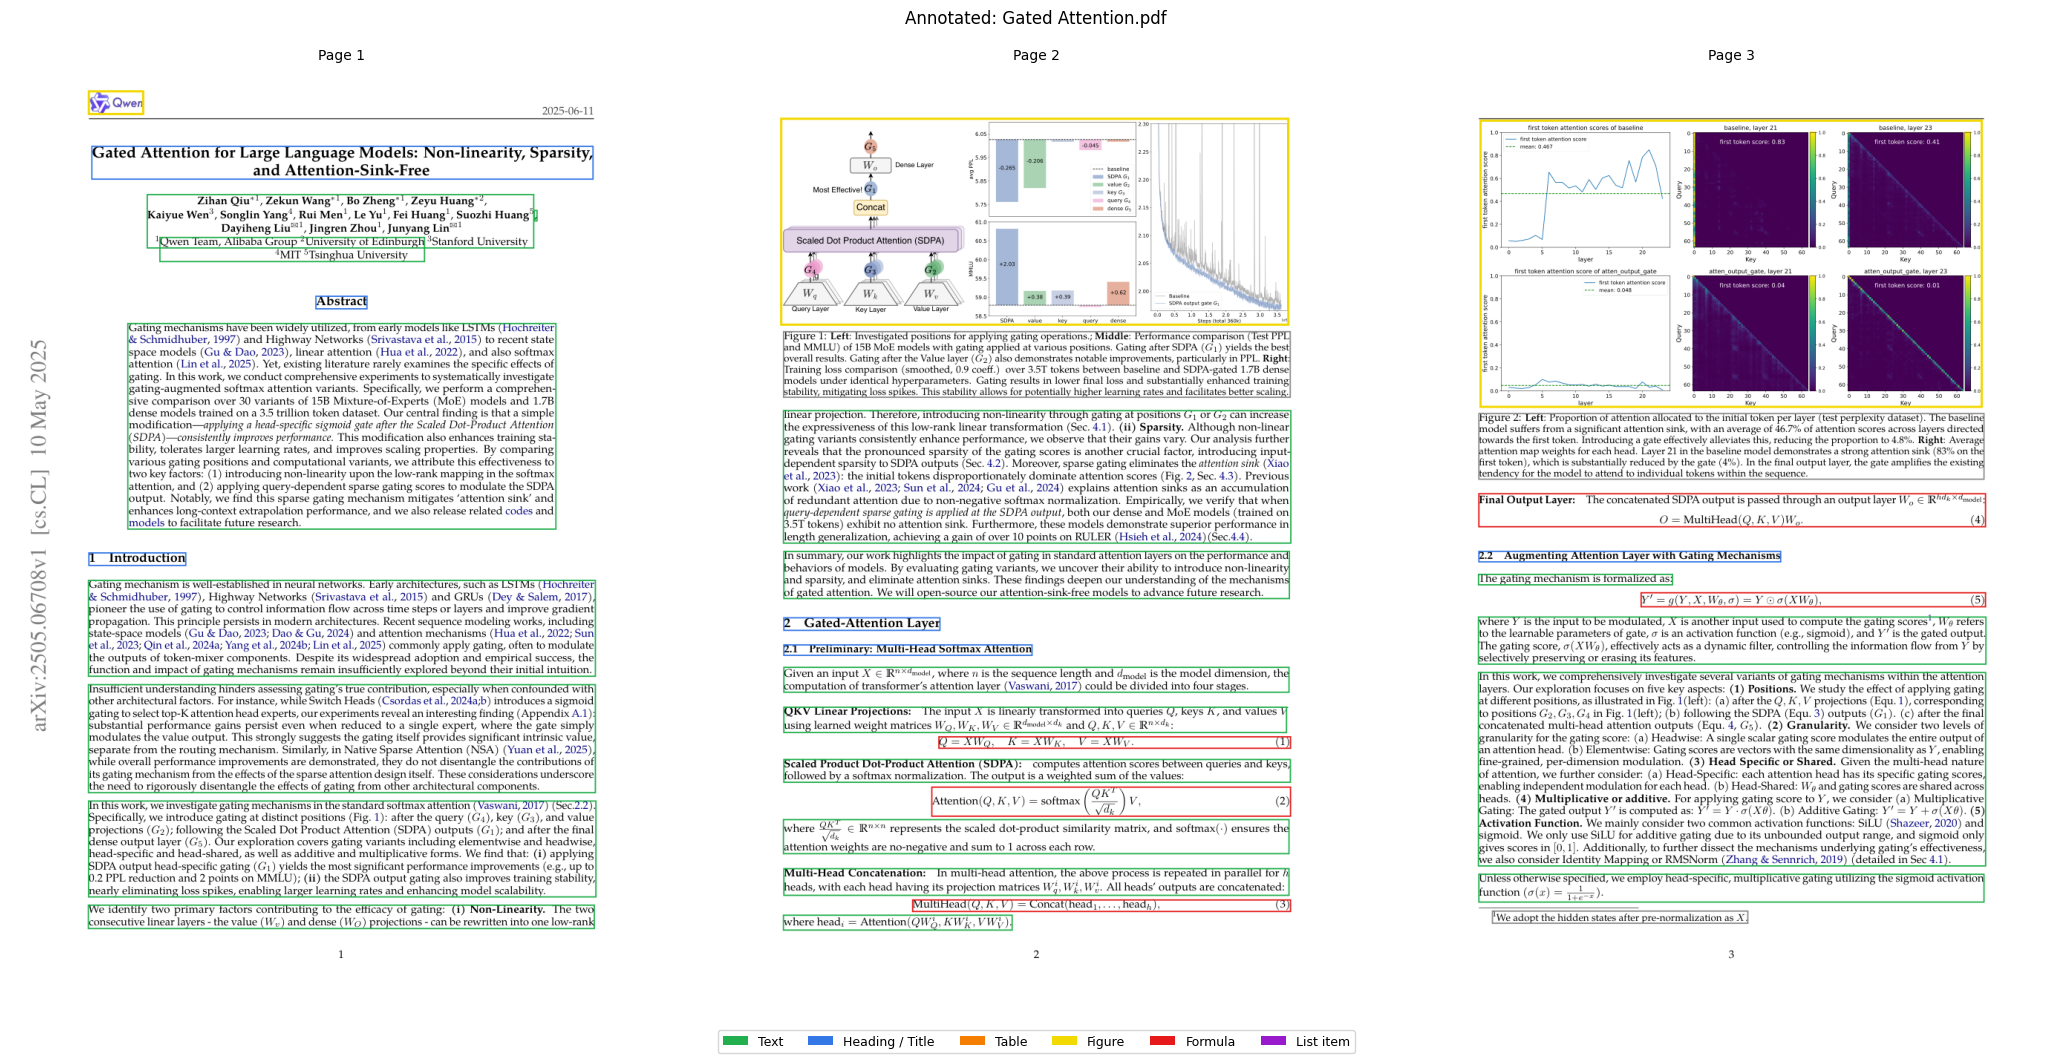

In [27]:
from PIL import Image
import io

# Preview the first N pages of the annotated PDF inline
PREVIEW_PAGES = 3
ZOOM = 1.5          # render resolution multiplier

pdf_preview = fitz.open(str(output_pdf))
mat = fitz.Matrix(ZOOM, ZOOM)

n_pages = min(PREVIEW_PAGES, len(pdf_preview))
fig, axes = plt.subplots(1, n_pages, figsize=(7 * n_pages, 10))
if n_pages == 1:
    axes = [axes]

for idx, ax in enumerate(axes):
    pix = pdf_preview[idx].get_pixmap(matrix=mat)
    img = Image.open(io.BytesIO(pix.tobytes("png")))
    ax.imshow(img)
    ax.set_title(f"Page {idx + 1}", fontsize=10)
    ax.axis("off")

pdf_preview.close()

# Legend
from matplotlib.patches import Patch
legend_items = [
    Patch(facecolor=(0.13, 0.69, 0.30), label="Text"),
    Patch(facecolor=(0.20, 0.47, 0.90), label="Heading / Title"),
    Patch(facecolor=(0.96, 0.49, 0.00), label="Table"),
    Patch(facecolor=(0.95, 0.85, 0.00), label="Figure"),
    Patch(facecolor=(0.90, 0.10, 0.10), label="Formula"),
    Patch(facecolor=(0.60, 0.10, 0.80), label="List item"),
]
fig.legend(handles=legend_items, loc="lower center", ncol=6,
           bbox_to_anchor=(0.5, -0.04), fontsize=9)
plt.suptitle(f"Annotated: {PDF_PATH.name}", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()
